In [2]:
import os

print(os.listdir("."))

['explore.ipynb', 'NaukriData_data analytics.csv', 'NaukriData_Data Science.csv', 'Naukri_Data_Scientist_and_Data_Analytics_Jobs_Data.csv']


In [4]:
import pandas as pd

df = pd.read_csv("NaukriData_data analytics.csv")
print(df.shape)
print(df.columns)
df.head()

(20064, 8)
Index(['Job_Titles', 'Company_Names', 'Experience_Required', 'Package_Details',
       'Locations', 'Skills', 'Post_Url', 'Post_Time'],
      dtype='str')


,Job_Titles,Company_Names,Experience_Required,Package_Details,Locations,Skills,Post_Url,Post_Time
0,"Lead Analyst, Data & Analytics",ANZ,4-6 Yrs,Not disclosed,Bangalore/Bengaluru,data cleansingData analysisAutomationData mana...,https://www.naukri.com/job-listings-lead-analy...,3 Days Ago
1,Director Data Analytics (Immediate Joiner pref...,Techneplus Software,10-15 Yrs,Not disclosed,"Noida, Uttar Pradesh, Bangalore/ Bengaluru, Ka...",Data ScienceData VisualizationData ModelingDat...,https://www.naukri.com/job-listings-director-d...,1 Day Ago
2,Data Analytics Lead,Gartner,5-8 Yrs,Not disclosed,Gurgaon/Gurugram,Process designChange managementProject managem...,https://www.naukri.com/job-listings-data-analy...,1 Day Ago
3,Data Analytics Analyst,Leading Indian IT Company,4-7 Yrs,Not disclosed,"Noida, Mumbai, Bangalore/Bengaluru",Data AnalysisRSASPower BIData VisualizationTab...,NaN,2 Days Ago
4,Data Analytics Analyst,Foreign MNC in BPO,7-9 Yrs,Not disclosed,Jaipur,Data AnalyticsData EngineeringScalaHadoopOLAPS...,NaN,1 Day Ago


In [6]:
print(df.columns.tolist())

['Job_Titles', 'Company_Names', 'Experience_Required', 'Package_Details', 'Locations', 'Skills', 'Post_Url', 'Post_Time']


In [7]:
mask = df['Job_Titles'].str.contains("data analyst", case=False, na=False)
data_analyst_jobs = df[mask]
print(len(data_analyst_jobs))
data_analyst_jobs.head()

1085


,Job_Titles,Company_Names,Experience_Required,Package_Details,Locations,Skills,Post_Url,Post_Time
11,Data Analyst - US MNC (analytics),Aspyra Hr Services,7-9 Yrs,Not disclosed,Chennai,SQL queriesData analysisData modelingProgrammi...,https://www.naukri.com/job-listings-data-analy...,4 Days Ago
30,Data Analyst SAS+VBA- US MNC (analytics),Aspyra Hr Services,2-5 Yrs,Not disclosed,Mumbai,ProcurementData analysisSAPAnalyticalpower biF...,https://www.naukri.com/job-listings-data-analy...,30+ Days Ago
33,Data Analyst / data Analytics - US MNC (analyt...,Aspyra Hr Services,6-8 Yrs,Not disclosed,"Gurgaon/Gurugram, Bangalore/ Bengaluru, Karnataka",Visual AnalyticsData Management And AnalysisSQ...,https://www.naukri.com/job-listings-data-analy...,29 Days Ago
46,Data Analyst Risk/Fraud strategy - US MNC (ana...,Aspyra Hr Services,0-3 Yrs,Not disclosed,Hyderabad/Secunderabad,advanced analyticsTalent acquisitionAnalytical...,https://www.naukri.com/job-listings-data-analy...,30+ Days Ago
51,Data Analyst Advanced Analytics,Perceptive Analytics,2-4 Yrs,Not disclosed,New Delhi,Data analysispower biData processingData quali...,https://www.naukri.com/job-listings-data-analy...,30+ Days Ago


In [9]:
mask = df['Job_Titles'].str.contains("data analyst", case=False, na=False)
data_analyst_jobs = df[mask]
print(len(data_analyst_jobs))
print(len(df))

1085
20064


In [10]:
import os
os.makedirs("../Processed", exist_ok=True)
data_analyst_jobs.to_csv("../Processed/data_analyst_filtered.csv", index=False)
print("Saved:", len(data_analyst_jobs), "rows")

Saved: 1085 rows


In [11]:
print(data_analyst_jobs['Skills'].iloc[0])
print(data_analyst_jobs['Skills'].iloc[1])

SQL queriesData analysisData modelingProgrammingData qualityData analyticsFinancial risk managementBusiness intelligence
ProcurementData analysisSAPAnalyticalpower biForensicData analyticsQlikView


Sample 1: SQL queriesData analysisData modelingProgrammingData qualityData analyticsFinancial risk managementBusiness intelligence
Sample 2: ProcurementData analysisSAPAnalyticalpower biForensicData analyticsQlikView
Type: <class 'str'>

Skill Frequency:
 Data_Analysis         477
Analytics             319
SQL                   273
Machine_Learning      150
Excel                 147
Data_Management       134
Python                133
Power_BI               95
Data_Visualization     84
Data_Modeling          79
Tableau                69
Reporting              63
SAS                    57
Data_Warehousing       33
Statistics             25
ETL                    13
VBA                     7
Dashboard               5
Data_Cleaning           4
R_programming           0
dtype: int64


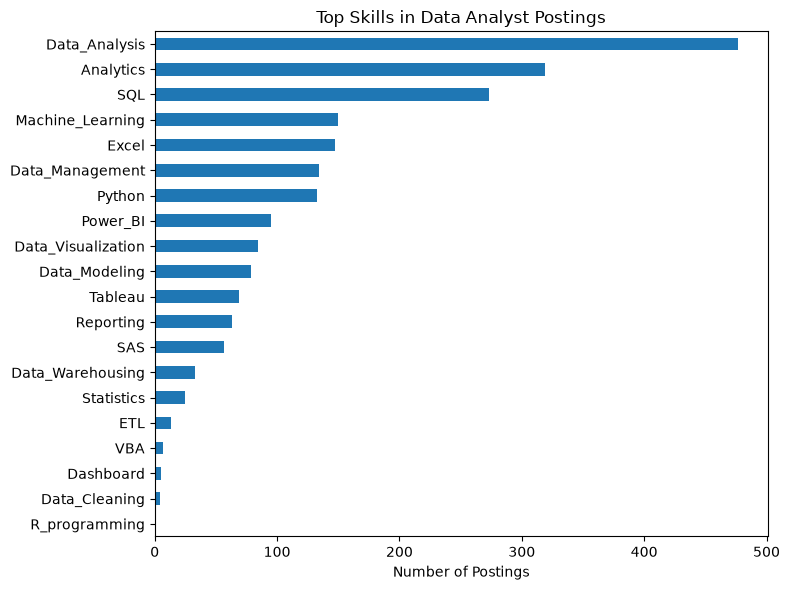

In [12]:
# 1. Skills column ka format dekhne ke liye
print("Sample 1:", data_analyst_jobs['Skills'].iloc[0])
print("Sample 2:", data_analyst_jobs['Skills'].iloc[1])
print("Type:", type(data_analyst_jobs['Skills'].iloc[0]))

# 2. Common skill keywords define karo (basic starting list)
skill_keywords = [
    "SQL", "Python", "Excel", "Power BI", "Tableau", "R programming",
    "Data Analysis", "Data Visualization", "Statistics", "Machine Learning",
    "Data Modeling", "SAS", "VBA", "Data Management", "Analytics",
    "Data Cleaning", "Reporting", "Dashboard", "ETL", "Data Warehousing"
]

# 3. Har posting mein har skill hai ya nahi, ye check karke columns bana do
skills_text = data_analyst_jobs['Skills'].astype(str)

for skill in skill_keywords:
    col_name = skill.replace(" ", "_")
    data_analyst_jobs[col_name] = skills_text.str.contains(skill, case=False, na=False)

# 4. Ab count nikaalo — kaunsi skill kitni baar aayi
skill_columns = [s.replace(" ", "_") for s in skill_keywords]
skill_counts = data_analyst_jobs[skill_columns].sum().sort_values(ascending=False)
print("\nSkill Frequency:\n", skill_counts)

# 5. Chart bana do
import matplotlib.pyplot as plt
skill_counts.plot(kind='barh', figsize=(8,6))
plt.title("Top Skills in Data Analyst Postings")
plt.xlabel("Number of Postings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
# STEP A: Skill frequency table save karo (report ke liye)
skill_freq_table = skill_counts.reset_index()
skill_freq_table.columns = ['Skill', 'Number_of_Postings']
skill_freq_table['Percentage'] = (skill_freq_table['Number_of_Postings'] / len(data_analyst_jobs) * 100).round(1)
skill_freq_table.to_csv("../Processed/skill_frequency.csv", index=False)
print(skill_freq_table)

# STEP B: Skill Gap Analyzer function
def skill_gap_analyzer(user_skills, top_n=10):
    top_skills = skill_counts.head(top_n).index.tolist()
    top_skills_clean = [s.replace("_", " ") for s in top_skills]
    user_skills_lower = [s.lower() for s in user_skills]

    have = [s for s in top_skills_clean if s.lower() in user_skills_lower]
    missing = [s for s in top_skills_clean if s.lower() not in user_skills_lower]

    print(f"\n✅ You already have ({len(have)}):")
    for s in have: print("   -", s)
    print(f"\n❌ You are missing ({len(missing)}):")
    for s in missing: print("   -", s)

    coverage = round(len(have) / top_n * 100, 1)
    print(f"\n📊 Coverage of top {top_n} market skills: {coverage}%")
    return have, missing

# Test karo apni skills daal ke:
my_skills = ["Python", "SQL", "Excel"]
have, missing = skill_gap_analyzer(my_skills, top_n=10)

                 Skill  Number_of_Postings  Percentage
0        Data_Analysis                 477        44.0
1            Analytics                 319        29.4
2                  SQL                 273        25.2
3     Machine_Learning                 150        13.8
4                Excel                 147        13.5
5      Data_Management                 134        12.4
6               Python                 133        12.3
7             Power_BI                  95         8.8
8   Data_Visualization                  84         7.7
9        Data_Modeling                  79         7.3
10             Tableau                  69         6.4
11           Reporting                  63         5.8
12                 SAS                  57         5.3
13    Data_Warehousing                  33         3.0
14          Statistics                  25         2.3
15                 ETL                  13         1.2
16                 VBA                   7         0.6
17        

In [15]:
import sys
!{sys.executable} -m pip install rapidfuzz

  Using cached rapidfuzz-3.14.6-cp313-cp313-win_amd64.whl.metadata (12 kB)
Using cached rapidfuzz-3.14.6-cp313-cp313-win_amd64.whl (1.7 MB)


In [16]:
from rapidfuzz import fuzz

def skill_present_fuzzy(skill, text, threshold=85):
    # Short skills (like "R", "Go", "AI") stay on exact match — 
    # fuzzy matching on very short strings causes false positives
    if len(skill) <= 3:
        return skill.lower() in text.lower()
    return fuzz.partial_ratio(skill.lower(), text.lower()) >= threshold

# Run fuzzy matching across all postings, for every skill
fuzzy_results = {}
for skill in skill_keywords:
    col_name = skill.replace(" ", "_") + "_fuzzy"
    fuzzy_results[col_name] = [skill_present_fuzzy(skill, t) for t in skills_text]

for col_name, values in fuzzy_results.items():
    data_analyst_jobs[col_name] = values

fuzzy_columns = list(fuzzy_results.keys())
fuzzy_counts = data_analyst_jobs[fuzzy_columns].sum().sort_values(ascending=False)
print(fuzzy_counts)

Data_Analysis_fuzzy         530
Analytics_fuzzy             503
SQL_fuzzy                   273
Data_Management_fuzzy       162
Machine_Learning_fuzzy      151
Excel_fuzzy                 147
Python_fuzzy                133
Power_BI_fuzzy               96
Data_Modeling_fuzzy          86
Data_Visualization_fuzzy     85
Tableau_fuzzy                71
Reporting_fuzzy              63
Statistics_fuzzy             62
SAS_fuzzy                    57
Data_Warehousing_fuzzy       33
Data_Cleaning_fuzzy          31
ETL_fuzzy                    13
R_programming_fuzzy          11
VBA_fuzzy                     7
Dashboard_fuzzy               5
dtype: int64


In [17]:
comparison = pd.DataFrame({
    'Exact_Match': skill_counts,
    'Fuzzy_Match': fuzzy_counts.rename(lambda x: x.replace('_fuzzy', ''))
})
comparison['Difference'] = comparison['Fuzzy_Match'] - comparison['Exact_Match']
print(comparison.sort_values('Difference', ascending=False))

                    Exact_Match  Fuzzy_Match  Difference
Analytics                   319          503         184
Data_Analysis               477          530          53
Statistics                   25           62          37
Data_Management             134          162          28
Data_Cleaning                 4           31          27
R_programming                 0           11          11
Data_Modeling                79           86           7
Tableau                      69           71           2
Data_Visualization           84           85           1
Machine_Learning            150          151           1
Power_BI                     95           96           1
Dashboard                     5            5           0
ETL                          13           13           0
Excel                       147          147           0
Data_Warehousing             33           33           0
Python                      133          133           0
SAS                          57

In [18]:
# Find postings where fuzzy caught "Analytics" but exact match didn't
newly_matched = data_analyst_jobs[
    (data_analyst_jobs['Analytics_fuzzy'] == True) & 
    (data_analyst_jobs['Analytics'] == False)
]
print(f"Newly matched count: {len(newly_matched)}")

# Look at 5 actual examples
for skill_text in newly_matched['Skills'].head(5):
    print("---")
    print(skill_text)

Newly matched count: 184
---
Data managementMS AccessProject managementAnalyticalConsultingVBOracleFinancial services
---
OutboundPublic relationsProduct engineeringAnalyticalBillingPHPInformation retrievalCustomer support
---
BPOComputer scienceBusiness servicesBusiness objectsAnalyticalSocial mediaCustomer supportOutsourcing
---
data managementmodelinganalyticalconsultinginterpersonal skillsproblem solvingdata mappingexcel
---
Statistical programmingData analysisAutomationAnalyticalMachine learningAgileOpen sourceSQL


In [22]:
from rapidfuzz import fuzz

def skill_present_fuzzy(skill, text, threshold=90):
    skill_lower = skill.lower()
    text_lower = text.lower()
    if len(skill) <= 6 or skill_lower in ["analytics", "analysis"]:
        return skill_lower in text_lower
    return fuzz.token_sort_ratio(skill_lower, text_lower) >= threshold

# Fuzzy matching dobara chalao, updated function ke saath
fuzzy_results = {}
for skill in skill_keywords:
    col_name = skill.replace(" ", "_") + "_fuzzy"
    fuzzy_results[col_name] = [skill_present_fuzzy(skill, t) for t in skills_text]

for col_name, values in fuzzy_results.items():
    data_analyst_jobs[col_name] = values

fuzzy_columns = list(fuzzy_results.keys())
fuzzy_counts = data_analyst_jobs[fuzzy_columns].sum().sort_values(ascending=False)

# Comparison table
comparison = pd.DataFrame({
    'Exact_Match': skill_counts,
    'Fuzzy_Match': fuzzy_counts.rename(lambda x: x.replace('_fuzzy', ''))
})
comparison['Difference'] = comparison['Fuzzy_Match'] - comparison['Exact_Match']
print(comparison.sort_values('Difference', ascending=False))

# Spot-check: Statistics ke naye matches sahi hain ya nahi
print("\n--- Statistics newly matched examples ---")
stats_new = data_analyst_jobs[
    (data_analyst_jobs['Statistics_fuzzy'] == True) & 
    (data_analyst_jobs['Statistics'] == False)
]
for s in stats_new['Skills'].head(3):
    print(s)

# Spot-check: Data_Cleaning ke naye matches sahi hain ya nahi
print("\n--- Data_Cleaning newly matched examples ---")
clean_new = data_analyst_jobs[
    (data_analyst_jobs['Data_Cleaning_fuzzy'] == True) & 
    (data_analyst_jobs['Data_Cleaning'] == False)
]
for s in clean_new['Skills'].head(3):
    print(s)

                    Exact_Match  Fuzzy_Match  Difference
Analytics                   319          319           0
R_programming                 0            0           0
ETL                          13           13           0
Excel                       147          147           0
SQL                         273          273           0
SAS                          57           57           0
Python                      133          133           0
VBA                           7            7           0
Data_Cleaning                 4            0          -4
Dashboard                     5            0          -5
Statistics                   25            0         -25
Data_Warehousing             33            0         -33
Reporting                    63            0         -63
Tableau                      69            0         -69
Data_Modeling                79            0         -79
Data_Visualization           84            0         -84
Power_BI                     95

In [23]:
import re
from rapidfuzz import fuzz

# Step 1: split the concatenated Skills string into individual items
def split_skills(text):
    if not isinstance(text, str):
        return []
    spaced = re.sub(r'(?<=[a-z])(?=[A-Z])', '|', text)  # insert separator at lowercase→uppercase boundary
    spaced = spaced.replace(',', '|')
    return [s.strip() for s in spaced.split('|') if s.strip()]

# Test it first on one example — check this looks right before continuing
sample_split = split_skills(data_analyst_jobs['Skills'].iloc[0])
print(sample_split)

['SQL queries', 'Data analysis', 'Data modeling', 'Programming', 'Data quality', 'Data analytics', 'Financial risk management', 'Business intelligence']


In [24]:
# Step 2: apply the split to the whole column and store it (you'll reuse this in Week 7 too)
data_analyst_jobs['Skills_list'] = data_analyst_jobs['Skills'].apply(split_skills)

# Step 3: fuzzy-match each target skill against EACH individual item, take the best score
def skill_present_fuzzy(skill, skills_list, threshold=85):
    skill_lower = skill.lower()

    # Short/generic skills stay exact-match only (protects against false positives)
    if len(skill) <= 6 or skill_lower in ["analytics", "analysis"]:
        return any(skill_lower == item.lower() or skill_lower in item.lower() for item in skills_list)

    # Compare against each individual split item, not the whole blob
    return any(fuzz.token_sort_ratio(skill_lower, item.lower()) >= threshold for item in skills_list)

# Step 4: re-run fuzzy matching using the split lists
fuzzy_results = {}
for skill in skill_keywords:
    col_name = skill.replace(" ", "_") + "_fuzzy"
    fuzzy_results[col_name] = [skill_present_fuzzy(skill, lst) for lst in data_analyst_jobs['Skills_list']]

for col_name, values in fuzzy_results.items():
    data_analyst_jobs[col_name] = values

fuzzy_columns = list(fuzzy_results.keys())
fuzzy_counts = data_analyst_jobs[fuzzy_columns].sum().sort_values(ascending=False)

# Step 5: comparison table
comparison = pd.DataFrame({
    'Exact_Match': skill_counts,
    'Fuzzy_Match': fuzzy_counts.rename(lambda x: x.replace('_fuzzy', ''))
})
comparison['Difference'] = comparison['Fuzzy_Match'] - comparison['Exact_Match']
print(comparison.sort_values('Difference', ascending=False))

# Step 6: spot-check two of the biggest increases (adjust names based on what you see above)
print("\n--- Spot-check: Data_Modeling ---")
check1 = data_analyst_jobs[
    (data_analyst_jobs['Data_Modeling_fuzzy'] == True) &
    (data_analyst_jobs['Data_Modeling'] == False)
]
for lst in check1['Skills_list'].head(3):
    print(lst)

print("\n--- Spot-check: Statistics ---")
check2 = data_analyst_jobs[
    (data_analyst_jobs['Statistics_fuzzy'] == True) &
    (data_analyst_jobs['Statistics'] == False)
]
for lst in check2['Skills_list'].head(3):
    print(lst)

                    Exact_Match  Fuzzy_Match  Difference
Data_Analysis               477          587         110
Data_Cleaning                 4           26          22
R_programming                 0           22          22
Analytics                   319          319           0
VBA                           7            7           0
Excel                       147          147           0
Python                      133          133           0
ETL                          13           13           0
SQL                         273          271          -2
SAS                          57           55          -2
Dashboard                     5            2          -3
Data_Warehousing             33           28          -5
Statistics                   25           20          -5
Data_Modeling                79           60         -19
Tableau                      69           45         -24
Machine_Learning            150          126         -24
Data_Management             134

In [25]:
def skill_present_fuzzy(skill, skills_list, threshold=88):
    skill_lower = skill.lower()
    # Short/generic skills: don't trust fuzzy at all, exact match already handles them
    if len(skill) <= 6 or skill_lower in ["analytics", "analysis"]:
        return False
    return any(fuzz.token_sort_ratio(skill_lower, item.lower()) >= threshold for item in skills_list)

fuzzy_results = {}
for skill in skill_keywords:
    col_name = skill.replace(" ", "_") + "_fuzzy"
    exact_flags = skills_text.str.contains(skill, case=False, na=False)
    fuzzy_only_flags = pd.Series([skill_present_fuzzy(skill, lst) for lst in data_analyst_jobs['Skills_list']])
    fuzzy_results[col_name] = exact_flags.values | fuzzy_only_flags.values

for col_name, values in fuzzy_results.items():
    data_analyst_jobs[col_name] = values

fuzzy_columns = list(fuzzy_results.keys())
fuzzy_counts = data_analyst_jobs[fuzzy_columns].sum().sort_values(ascending=False)

comparison = pd.DataFrame({
    'Exact_Match': skill_counts,
    'Fuzzy_Match': fuzzy_counts.rename(lambda x: x.replace('_fuzzy', ''))
})
comparison['Difference'] = comparison['Fuzzy_Match'] - comparison['Exact_Match']
print(comparison.sort_values('Difference', ascending=False))

                    Exact_Match  Fuzzy_Match  Difference
Data_Analysis               477          653         176
Data_Cleaning                 4           28          24
R_programming                 0           22          22
Data_Management             134          137           3
Data_Modeling                79           81           2
Data_Visualization           84           85           1
Analytics                   319          319           0
Dashboard                     5            5           0
ETL                          13           13           0
Excel                       147          147           0
Machine_Learning            150          150           0
Data_Warehousing             33           33           0
Power_BI                     95           95           0
Python                      133          133           0
Reporting                    63           63           0
SAS                          57           57           0
SQL                         273

In [27]:
import sys
!{sys.executable} -m pip install networkx

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 15.7 MB/s  0:00:00


          Skill_A             Skill_B  Co_occurrence_Count
0       Analytics       Data Analysis                  208
6   Data Analysis                 SQL                  164
48  Data Analysis               Excel                   92
3       Analytics                 SQL                   83
18  Data Analysis    Machine Learning                   81
76         Python                 SQL                   72
14  Data Analysis     Data Management                   69
49  Data Analysis              Python                   68
11  Data Analysis            Power BI                   60
17      Analytics    Machine Learning                   59
21  Data Analysis  Data Visualization                   56
30      Analytics              Python                   49
4   Data Analysis       Data Modeling                   49
32  Data Analysis             Tableau                   47
12       Power BI                 SQL                   45


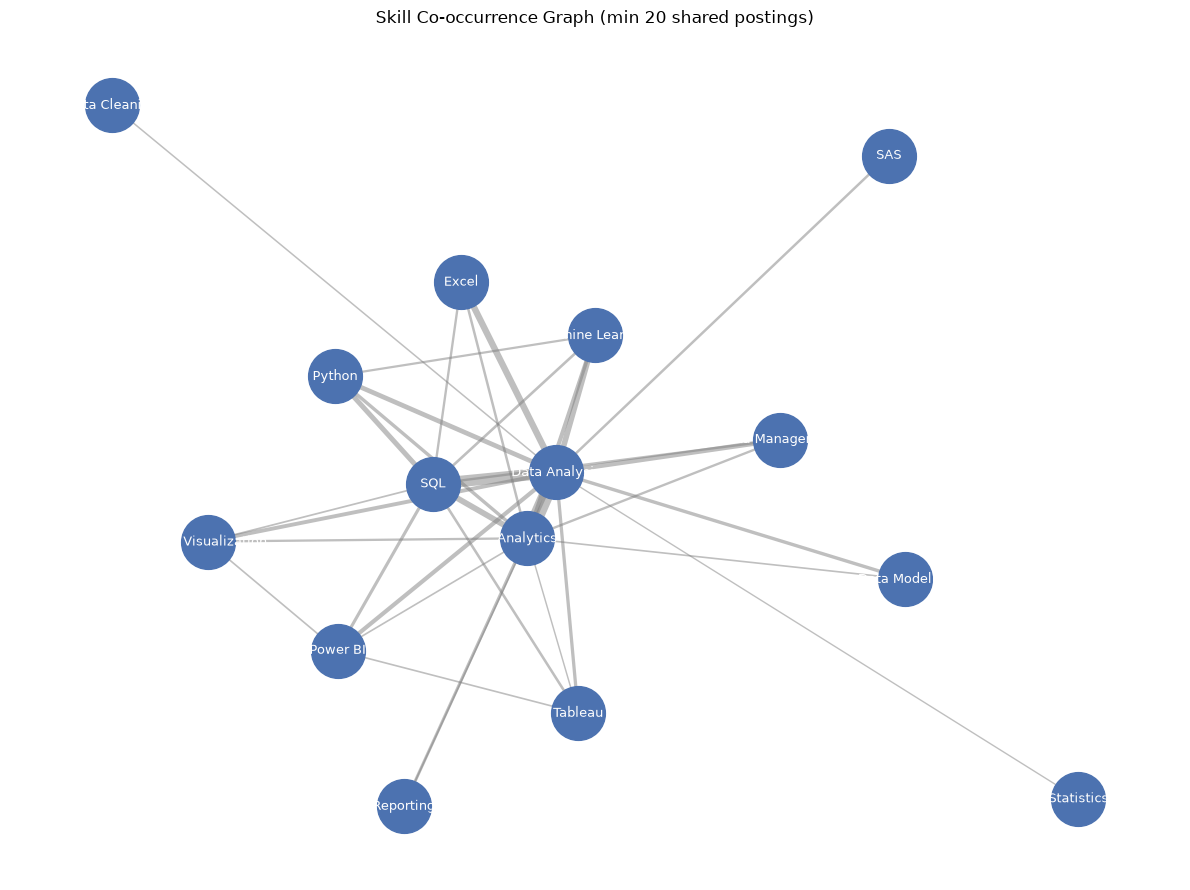


Total skill pairs found: 154
Strong pairs shown in graph (>=20): 34
Nodes in graph: 15, Edges: 34


In [28]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# STEP 1: Build the final skill list per posting using BOTH exact + fuzzy results
# (columns ending in _fuzzy already contain exact OR fuzzy combined)
final_skill_cols = [s.replace(" ", "_") + "_fuzzy" for s in skill_keywords]

def get_present_skills(row):
    return [skill_keywords[i] for i, col in enumerate(final_skill_cols) if row[col]]

data_analyst_jobs['present_skills'] = data_analyst_jobs.apply(get_present_skills, axis=1)

# STEP 2: Count how often every PAIR of skills appears together in the same posting
pair_counts = {}
for skills in data_analyst_jobs['present_skills']:
    for pair in combinations(sorted(set(skills)), 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

# STEP 3: Turn into a clean table, save for your report
pair_df = pd.DataFrame(
    [(a, b, count) for (a, b), count in pair_counts.items()],
    columns=['Skill_A', 'Skill_B', 'Co_occurrence_Count']
).sort_values('Co_occurrence_Count', ascending=False)

pair_df.to_csv("../Processed/skill_cooccurrence.csv", index=False)
print(pair_df.head(15))

# STEP 4: Build and draw the network graph — only strong pairs, to keep it readable
MIN_COOCCURRENCE = 20  # tweak this if graph looks too busy or too empty
strong_pairs = pair_df[pair_df['Co_occurrence_Count'] >= MIN_COOCCURRENCE]

G = nx.Graph()
for _, row in strong_pairs.iterrows():
    G.add_edge(row['Skill_A'], row['Skill_B'], weight=row['Co_occurrence_Count'])

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, k=0.8, seed=42)
weights = [G[u][v]['weight'] / 20 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='#4C72B0')
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white')
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.5, edge_color='gray')

plt.title(f"Skill Co-occurrence Graph (min {MIN_COOCCURRENCE} shared postings)")
plt.axis('off')
plt.tight_layout()
plt.savefig("../Processed/skill_graph.png", dpi=150)
plt.show()

# STEP 5: Save the graph structure too (useful later for learning-path logic in V3)
import pickle
with open("../Processed/skill_graph.pkl", "wb") as f:
    pickle.dump(G, f)

print(f"\nTotal skill pairs found: {len(pair_df)}")
print(f"Strong pairs shown in graph (>={MIN_COOCCURRENCE}): {len(strong_pairs)}")
print(f"Nodes in graph: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

In [29]:
# STEP 1: Doosra role load karo — Data Scientist
df_ds_raw = pd.read_csv("Naukri_Data_Scientist_and_Data_Analytics_Jobs_Data.csv")
print("Columns:", df_ds_raw.columns.tolist())
print("Total rows:", len(df_ds_raw))

Columns: ['Job Titles', 'Company Names', 'Experience Required', 'Package', 'Locations', 'Skills']
Total rows: 19649


In [30]:
# STEP 1: Filter for Data Scientist postings
mask_ds = df_ds_raw['Job Titles'].str.contains("data scientist", case=False, na=False)
data_scientist_jobs = df_ds_raw[mask_ds].copy()
print("Data Scientist postings found:", len(data_scientist_jobs))

# STEP 2: Rename columns to match your Data Analyst dataset structure (so both can share the same functions)
data_scientist_jobs = data_scientist_jobs.rename(columns={
    'Job Titles': 'Job_Titles',
    'Company Names': 'Company_Names'
})

# STEP 3: Split skills using the SAME function you already built (Week 5/7) — no need to redefine it
data_scientist_jobs['Skills_list'] = data_scientist_jobs['Skills'].astype(str).apply(split_skills)

# STEP 4: Tag each dataset with its role, then combine into one master dataset
data_analyst_jobs['Role'] = 'Data Analyst'
data_scientist_jobs['Role'] = 'Data Scientist'

combined_jobs = pd.concat([data_analyst_jobs, data_scientist_jobs], ignore_index=True)
print("\nCombined dataset size:", len(combined_jobs))
print(combined_jobs['Role'].value_counts())

# STEP 5: Extract skill presence for Data Scientist postings using your existing skill_keywords list
ds_skills_text = data_scientist_jobs['Skills'].astype(str)
for skill in skill_keywords:
    col_name = skill.replace(" ", "_")
    data_scientist_jobs[col_name] = ds_skills_text.str.contains(skill, case=False, na=False)

# STEP 6: Compare skill frequency between the two roles — this is the actual point of Week 8
skill_cols_plain = [s.replace(" ", "_") for s in skill_keywords]

da_pct = (data_analyst_jobs[skill_cols_plain].sum() / len(data_analyst_jobs) * 100).round(1)
ds_pct = (data_scientist_jobs[skill_cols_plain].sum() / len(data_scientist_jobs) * 100).round(1)

role_comparison = pd.DataFrame({
    'Data_Analyst_%': da_pct,
    'Data_Scientist_%': ds_pct
})
role_comparison['Difference'] = (role_comparison['Data_Scientist_%'] - role_comparison['Data_Analyst_%']).round(1)
role_comparison = role_comparison.sort_values('Difference', ascending=False)

role_comparison.to_csv("../Processed/role_comparison_DA_vs_DS.csv")
print("\n", role_comparison)

# STEP 7: Save the combined dataset too
combined_jobs.to_csv("../Processed/combined_multirole_jobs.csv", index=False)

Data Scientist postings found: 1767

Combined dataset size: 2852
Role
Data Scientist    1767
Data Analyst      1085
Name: count, dtype: int64

                     Data_Analyst_%  Data_Scientist_%  Difference
Machine_Learning              13.8              26.7        12.9
Analytics                     29.4              32.8         3.4
Python                        12.3              15.2         2.9
Data_Modeling                  7.3               9.0         1.7
Data_Warehousing               3.0               3.5         0.5
Statistics                     2.3               2.8         0.5
ETL                            1.2               1.6         0.4
Dashboard                      0.5               0.6         0.1
R_programming                  0.0               0.1         0.1
SQL                           25.2              25.1        -0.1
VBA                            0.6               0.4        -0.2
Data_Cleaning                  0.4               0.2        -0.2
SAS        

In [31]:
print(data_analyst_jobs['Post_Time'].value_counts())

Post_Time
30+ Days Ago             642
1 Day Ago                 54
15 Days Ago               33
2 Days Ago                28
4 Days Ago                23
23 Days Ago               23
7 Days Ago                21
18 Days Ago               19
16 Days Ago               18
17 Days Ago               18
24 Days Ago               17
29 Days Ago               16
10 Days Ago               16
11 Days Ago               16
22 Days Ago               15
8 Days Ago                14
9 Days Ago                13
3 Days Ago                13
30 Days Ago               11
14 Days Ago               10
20 Days Ago                9
21 Days Ago                9
28 Days Ago                9
Starts in 1-3 months       7
6 Days Ago                 5
12 Days Ago                5
25 Days Ago                5
13 Days Ago                4
5 Days Ago                 3
27 Days Ago                3
19 Days Ago                2
Starts within 1 month      2
Just Now                   1
26 Days Ago                1
Name

In [32]:
import networkx as nx

# Reload the graph you saved in Week 7, in case kernel was restarted
with open("../Processed/skill_graph.pkl", "rb") as f:
    G = nx.read_gpickle(f) if hasattr(nx, 'read_gpickle') else pickle.load(f)

# --- PART A: Personalized Learning Path ---
def suggest_learning_path(user_skills, top_n=10):
    user_skills_lower = [s.lower() for s in user_skills]
    top_skills = skill_counts.head(top_n).index.tolist()
    top_skills_clean = [s.replace("_", " ") for s in top_skills]

    missing = [s for s in top_skills_clean if s.lower() not in user_skills_lower]

    # Rank missing skills by how many OTHER missing skills they co-occur with
    # (skills that are "hubs" among what's missing get suggested first)
    scores = {}
    for skill in missing:
        node_name = skill  # graph nodes were stored using skill_keywords names
        if node_name in G:
            connections_to_missing = sum(1 for neighbor in G.neighbors(node_name) if neighbor in missing)
            scores[skill] = connections_to_missing
        else:
            scores[skill] = 0

    ordered = sorted(missing, key=lambda s: scores.get(s, 0), reverse=True)

    print(f"\n📚 Suggested Learning Order ({len(ordered)} skills):")
    for i, skill in enumerate(ordered, 1):
        print(f"   {i}. {skill}  (connects to {scores.get(skill,0)} other missing skills)")
    return ordered

# Test it
my_skills = ["Python", "SQL", "Excel"]
learning_path = suggest_learning_path(my_skills, top_n=10)

# --- PART B: "Don't Learn This Yet" ---
def dont_learn_yet(hype_skills, role_threshold_pct=8):
    print(f"\n⏳ Don't Prioritize Yet (appear in <{role_threshold_pct}% of {len(data_analyst_jobs)} postings for this role):")
    for skill in hype_skills:
        col = skill.replace(" ", "_")
        if col in skill_counts.index:
            pct = round(skill_counts[col] / len(data_analyst_jobs) * 100, 1)
        else:
            pct = 0.0
        if pct < role_threshold_pct:
            print(f"   - {skill}: only {pct}% of postings mention this")

# Test with some commonly hyped skills
hype_list = ["Machine Learning", "R programming", "Statistics", "ETL", "Data Warehousing"]
dont_learn_yet(hype_list)


📚 Suggested Learning Order (7 skills):
   1. Data Analysis  (connects to 6 other missing skills)
   2. Analytics  (connects to 6 other missing skills)
   3. Power BI  (connects to 3 other missing skills)
   4. Data Visualization  (connects to 3 other missing skills)
   5. Machine Learning  (connects to 2 other missing skills)
   6. Data Management  (connects to 2 other missing skills)
   7. Data Modeling  (connects to 2 other missing skills)

⏳ Don't Prioritize Yet (appear in <8% of 1085 postings for this role):
   - R programming: only 0.0% of postings mention this
   - Statistics: only 2.3% of postings mention this
   - ETL: only 1.2% of postings mention this
   - Data Warehousing: only 3.0% of postings mention this


In [33]:
GENERIC_TERMS = ["Data Analysis", "Analytics"]

def suggest_learning_path(user_skills, top_n=10, exclude_generic=True):
    user_skills_lower = [s.lower() for s in user_skills]
    top_skills = skill_counts.head(top_n).index.tolist()
    top_skills_clean = [s.replace("_", " ") for s in top_skills]

    if exclude_generic:
        top_skills_clean = [s for s in top_skills_clean if s not in GENERIC_TERMS]

    missing = [s for s in top_skills_clean if s.lower() not in user_skills_lower]

    scores = {}
    for skill in missing:
        if skill in G:
            connections_to_missing = sum(1 for n in G.neighbors(skill) if n in missing)
            scores[skill] = connections_to_missing
        else:
            scores[skill] = 0

    ordered = sorted(missing, key=lambda s: scores.get(s, 0), reverse=True)
    print(f"\n📚 Suggested Learning Order ({len(ordered)} skills):")
    for i, skill in enumerate(ordered, 1):
        print(f"   {i}. {skill}  (connects to {scores.get(skill,0)} other missing skills)")
    return ordered

learning_path = suggest_learning_path(my_skills, top_n=10)


📚 Suggested Learning Order (5 skills):
   1. Power BI  (connects to 1 other missing skills)
   2. Data Visualization  (connects to 1 other missing skills)
   3. Machine Learning  (connects to 0 other missing skills)
   4. Data Management  (connects to 0 other missing skills)
   5. Data Modeling  (connects to 0 other missing skills)
